# 3.3 Linearisable Nonlinear Regression

In [2]:
using CairoMakie

Sometimes it is better to fit the data to nonlinear functions for example.  Some common functions are



Exponential: $y=p e^{rx}$

Power laws: $y=px^{r}$

or

$
y=p \frac{x}{r+x}  
$

At first glance of the models above, you might think that you cannot use least squares regression (because the functions do not appear to be linear in terms of the coefficients $p$ and $q$.  However, observe that for the relationships mentioned above, we can make them into equations that are linear in terms of $p$ and $q$

\begin{align}
y&=p e^{rx}& \Rightarrow \ln{y} &= r x +\ln{p} \\
y&=p x^r&  \Rightarrow \ln{y} &=r \ln{x} +\ln{p} \\
\end{align}


\begin{align}
y&=p \frac{x}{r+x}&  \Rightarrow \left(\frac{1}{y}\right) &= \left(\frac{r}{p}\right)\left(\frac{1}{x}\right) + \frac{1}{p}
\end{align}

So for the model $y=px^{r}$, if you take the natural log of both sides, $\ln y$ is linear with respect to r (but $y$ is NOT linear with respect to $r$).  Similarly for the model $y=px/(r+x)$, $1/y$ is linear with respect to $r/p$ and $1/p$.  See illustration below. 

<figure>
  <img src="../figures/03p01Fig01.png" alt="Description of the figure" width="100%">
  <figcaption>Figure 1: Linearisation of nonlinear functions</figcaption>
</figure>

A linear problem now appears and solutions can be found as in the linear least squares approach ($f_{model}(x)=a_0+a_1x$). So you can use any of the previious techniques  to fit this linear function. 

I will illustrate with an example.  Suppose you are given the data set below

In [3]:
xdata=[0, 
0.5,
1.0,
1.5,
2.0,
2.5,
3.0,
3.5,
4.0,
4.5,
5.0]
ydata=[6.00,
4.83,
3.70,
3.15,
2.41,
1.83,
1.49,
1.21,
0.96,
0.73,
0.64]

11-element Vector{Float64}:
 6.0
 4.83
 3.7
 3.15
 2.41
 1.83
 1.49
 1.21
 0.96
 0.73
 0.64

Plot this data to see how it looks like

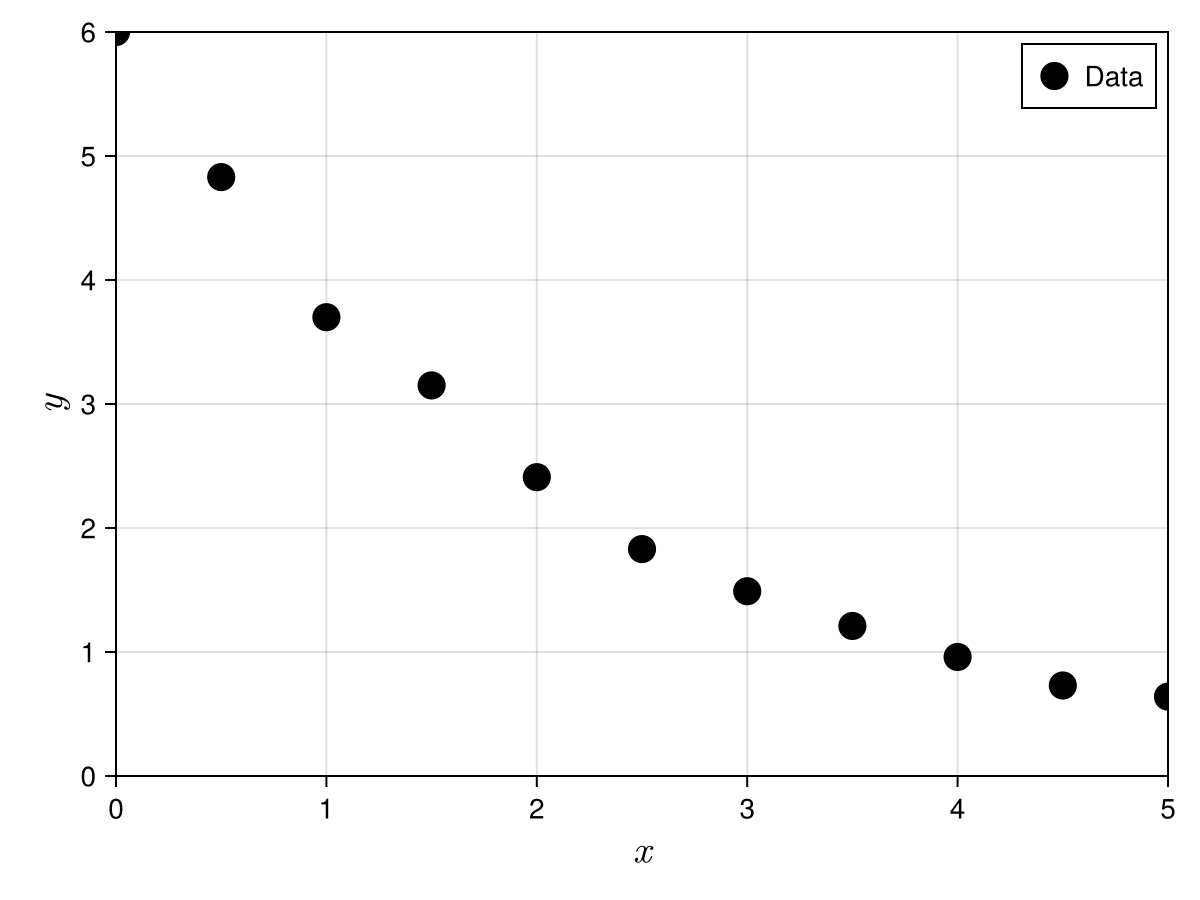

In [9]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    xlabelsize=20,
    ylabelsize=20,
    limits=(0,5,0,6))
scatter!(ax,xdata,ydata;label="Data",color=:black,markersize=20)
save("../figures/03p03LinearisableNonlinearRegression01.svg",fig)
axislegend(ax;position = :rt)
fig

Clearly a straight line is not going to fit this data well. You are asked to fit an exponential function 
of the form

$y=pe^{rx}$

to this data.  The idea is to make this function look like $y=a_0+a_1x$ and then use the method taught in the last notebook.
  
If you take the natural log both sides, you should get

$\ln(y)=rx +\ln(p)$


$y\rightarrow \ln(y)$

$x\rightarrow x$

$a_1\rightarrow r$

$a_0 \rightarrow \ln p$

So for this model, the $x$ values remain the same but we need to fit $\log$ of the $y$ values.

In [11]:
x=xdata
y=log.(ydata)

11-element Vector{Float64}:
  1.791759469228055
  1.5748464676644813
  1.308332819650179
  1.1474024528375417
  0.8796267475025636
  0.6043159668533296
  0.3987761199573678
  0.1906203596086497
 -0.040821994520255166
 -0.31471074483970024
 -0.4462871026284195

Now let's plot $x$ and $\log(y)$ to see how it looks like

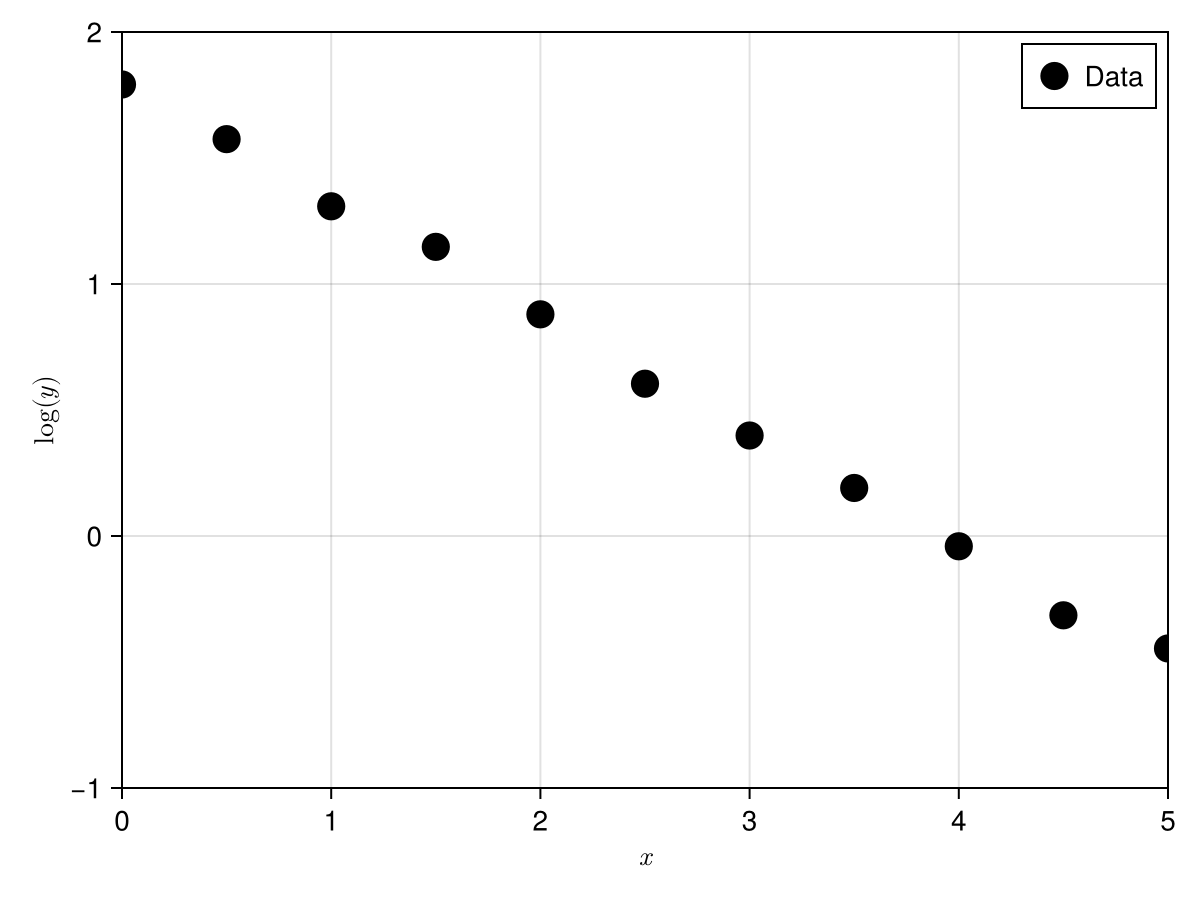

In [13]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"\log(y)",limits=(0,5,-1,2))
scatter!(ax,x,y;label="Data",color=:black,markersize=20)
save("../figures/03p03LinearisableNonlinearRegression02.svg",fig)
axislegend(ax;position = :rt)
fig

This looks very similar now to a straight line.  So we should be able to fit the data to this line.  We use the least squares formula

In [14]:
V=hcat(ones(length(xdata)),xdata)
a=V'*V\(V'*y)

2-element Vector{Float64}:
  1.789911913110954
 -0.45800619937842535

Let's plot the fit to see if does a good job

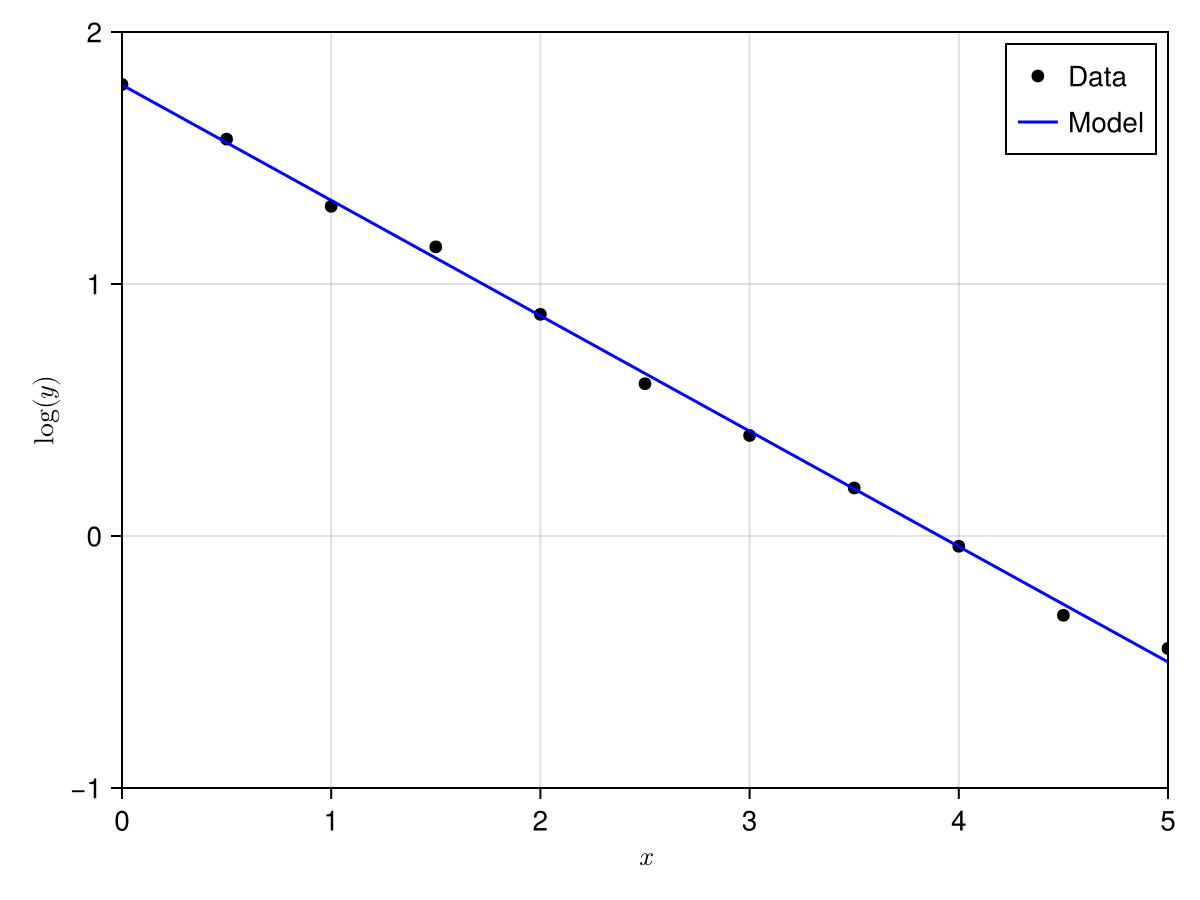

In [15]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"\log(y)",limits=(0,5,-1,2))
scatter!(ax,x,y;label="Data",color=:black)
lines!(ax,x,a[1].+a[2]*x;label="Model",color=:blue)
axislegend(ax;position = :rt)
fig

The model fits the data pretty well!

Now we transform the equations back to real varialbles and plot

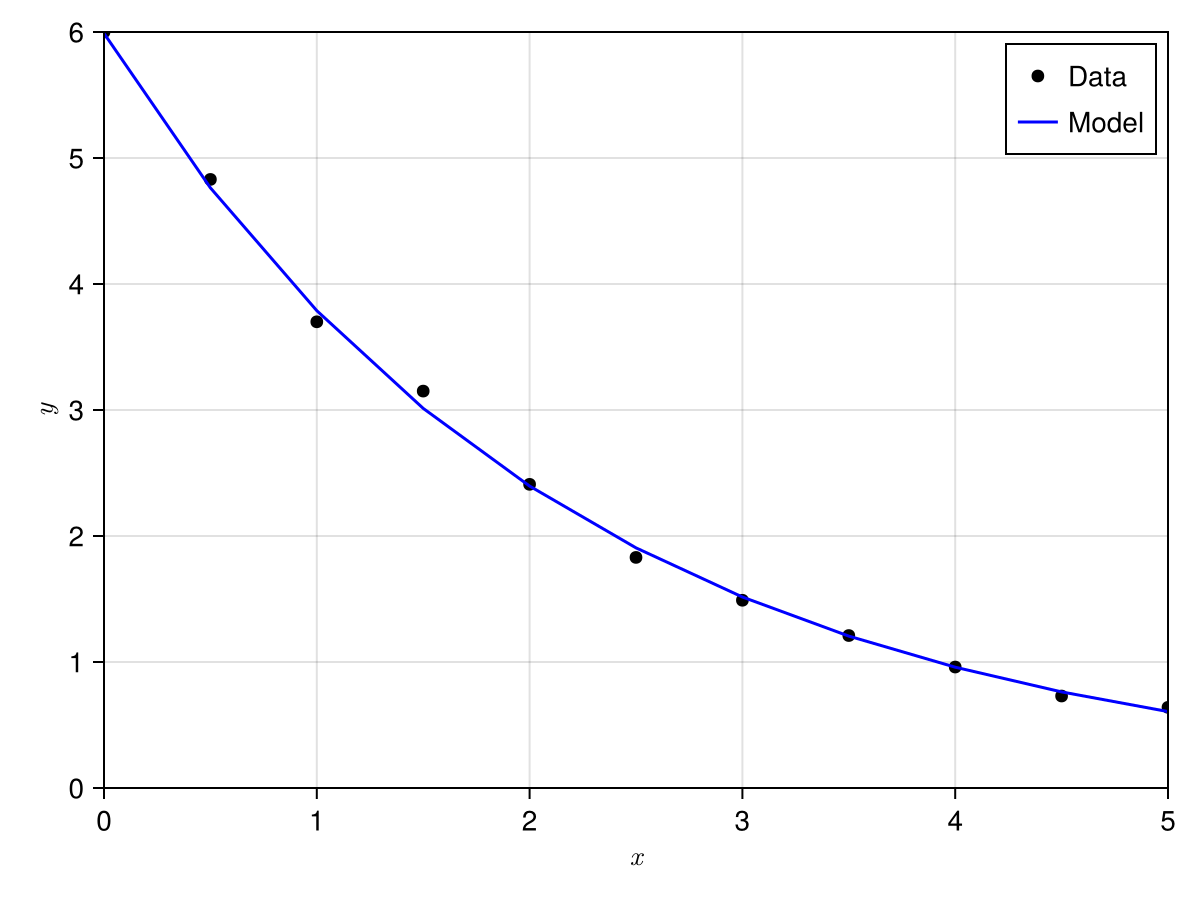

In [47]:
r=a[2]
p=exp(a[1])

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(0,5,0,6))
scatter!(ax,xdata,ydata;label="Data",color=:black)
lines!(ax,x,p.*exp.(r*x);label="Model",color=:blue)
axislegend(ax;position = :rt)
fig

Exercise:How do you change the code above to fit the function

$y=a+bx^2+ce^{-x}$

You want to find $a$, $b$ and $c$.

Prepared by Andrew Ooi 9th July 2026